# NYC Airbnb Price Prediction — Exploratory Data Analysis
**DATASCI 347: Machine Learning · Spring 2026**  
Dataset: [New York City Airbnb Open Data (2019)](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)  
Target: `log(price)` · n = 48,870 · 16 raw features

---

## 0 · Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, normaltest
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F9F9F9',
    'axes.edgecolor':    '#CCCCCC',
    'axes.labelcolor':   '#1A1A2E',
    'axes.titlecolor':   '#1A1A2E',
    'axes.titlesize':    12,
    'axes.labelsize':    10,
    'xtick.color':       '#1A1A2E',
    'ytick.color':       '#1A1A2E',
    'grid.color':        '#E5E7EB',
    'grid.linewidth':    0.5,
    'text.color':        '#1A1A2E',
    'figure.titlesize':  14,
    'font.family':       'monospace',
    'legend.facecolor':  '#1c1c1c',
    'legend.edgecolor':  '#CCCCCC',
    'legend.fontsize':   9,
})

ACCENT  = '#e8c547'
ACCENT2 = '#c8773a'
ACCENT3 = '#6bbfa0'
ACCENT4 = '#7b9cce'
DANGER  = '#c45c5c'
MUTED   = '#7a7870'

print("Libraries loaded ✓")

Libraries loaded ✓


---
## 1 · Data Loading & Initial Inspection

In [2]:
df = pd.read_csv('data/AB_NYC_2019.csv')
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")

Shape: (48895, 16)

Column dtypes:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [3]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])

Missing values per column:
name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64


In [4]:
df.describe().round(2)

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.00,4.889500e+04,48895.00,48895.00,48895.00,48895.00,48895.00,38843.00,48895.00,48895.00
mean,19017143.24,6.762001e+07,40.73,-73.95,152.72,7.03,23.27,1.37,7.14,112.78
std,10983108.39,7.861097e+07,0.05,0.05,240.15,20.51,44.55,1.68,32.95,131.62
min,2539.00,2.438000e+03,40.50,-74.24,0.00,1.00,0.00,0.01,1.00,0.00
25%,9471945.00,7.822033e+06,40.69,-73.98,69.00,1.00,1.00,0.19,1.00,0.00
50%,19677284.00,3.079382e+07,40.72,-73.96,106.00,3.00,5.00,0.72,1.00,45.00
75%,29152178.50,1.074344e+08,40.76,-73.94,175.00,5.00,24.00,2.02,2.00,227.00
max,36487245.00,2.743213e+08,40.91,-73.71,10000.00,1250.00,629.00,58.50,327.00,365.00


### Missing value diagnosis

| Column | Missing | Mechanism | Treatment |
|---|---|---|---|
| `name`, `host_name` | 16 / 21 | MCAR (negligible) | Drop column |
| `last_review` | 10,052 | MNAR — only when 0 reviews | Drop column |
| `reviews_per_month` | 10,052 | **MNAR** — exactly where `number_of_reviews == 0` | Fill with **0** |

> **MNAR (Missing Not At Random):** The missingness is caused by the value itself (no reviews → no rate).  
> Mean/median imputation would be statistically misleading here — zero is the correct value semantically.

In [5]:
# Verify MNAR hypothesis: all missing reviews_per_month ↔ number_of_reviews == 0
mask_no_review = df['number_of_reviews'] == 0
mask_rpm_null  = df['reviews_per_month'].isnull()

print(f"rows with 0 reviews:               {mask_no_review.sum():>6,}")
print(f"rows with reviews_per_month null:  {mask_rpm_null.sum():>6,}")
print(f"MNAR confirmed (sets identical):   {(mask_no_review == mask_rpm_null).all()}")

rows with 0 reviews:               10,052
rows with reviews_per_month null:  10,052
MNAR confirmed (sets identical):   True


---
## 2 · Data Cleaning & Filtering Decisions

In [6]:
df_clean = df.copy()

# ── Remove price = 0 ───────────────────────────────────────────────────────
# log(0) is undefined; these are almost certainly data entry errors.
n_price0 = (df_clean['price'] == 0).sum()
df_clean = df_clean[df_clean['price'] > 0]
print(f"Removed price=0:             {n_price0:>3} rows")

# ── Remove minimum_nights > 365 ────────────────────────────────────────────
# A listing requiring >1 year minimum stay is a long-term lease, not an
# Airbnb short-term rental. These are structurally different products.
n_min365 = (df_clean['minimum_nights'] > 365).sum()
df_clean = df_clean[df_clean['minimum_nights'] <= 365]
print(f"Removed minimum_nights>365:  {n_min365:>3} rows")

# ── Impute reviews_per_month (MNAR → 0) ───────────────────────────────────
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

# ── Log-transform target ───────────────────────────────────────────────────
df_clean['log_price'] = np.log(df_clean['price'])

# ── Drop non-predictive identifier columns ─────────────────────────────────
# 'name' (listing description) is retained for text feature extraction in
# the Feature Engineering notebook.
drop_cols = ['id', 'host_id', 'host_name', 'last_review']
df_clean = df_clean.drop(columns=drop_cols)

print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"Columns retained:    {df_clean.columns.tolist()}")
print(f"\nNote: 'name' kept for text feature extraction in Feature Engineering phase.")


Removed price=0:              11 rows
Removed minimum_nights>365:   14 rows

Final dataset shape: (48870, 13)
Columns retained:    ['name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'log_price']

Note: 'name' kept for text feature extraction in Feature Engineering phase.


In [7]:
# Export cleaned dataset for use in subsequent modelling notebooks
df_clean.to_csv('data/AB_NYC_2019_clean.csv', index=False)
print(f'Exported AB_NYC_2019_clean.csv — shape: {df_clean.shape}')
print(f'Columns: {df_clean.columns.tolist()}')

# Reload from csv — all EDA below uses this file, not the in-memory object
df_clean = pd.read_csv('data/AB_NYC_2019_clean.csv')
print(f'\nReloaded from csv — shape: {df_clean.shape}')


Exported AB_NYC_2019_clean.csv — shape: (48870, 13)
Columns: ['name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'log_price']



Reloaded from csv — shape: (48870, 13)


### Extreme price outliers (price > 1,000): retained

The top 0.3% of listings (price > $1,000) are luxury or event properties. We **retain** them because:
- The `log` transform compresses their leverage substantially.
- Removing them would silently discard information the model may usefully capture.
- A **sensitivity analysis** will re-run the best model after removing rows above the 99th percentile (p99 = $799).

In [8]:
p99 = df_clean['price'].quantile(0.99)
print(f"99th percentile price: ${p99:.0f}")
print(f"Rows above p99:        {(df_clean['price'] > p99).sum()} ({(df_clean['price'] > p99).mean()*100:.2f}%)")

# Preview extreme listings
df_clean[df_clean['price'] > 1000][
    ['neighbourhood_group','room_type','price','minimum_nights','availability_365']
].sort_values('price', ascending=False).head(8)

99th percentile price: $799
Rows above p99:        474 (0.97%)


,neighbourhood_group,room_type,price,minimum_nights,availability_365
9146,Queens,Private room,10000,100,0
17682,Brooklyn,Entire home/apt,10000,5,0
29216,Manhattan,Entire home/apt,10000,30,83
6527,Manhattan,Entire home/apt,9999,5,0
12335,Manhattan,Private room,9999,99,83
40409,Manhattan,Entire home/apt,9999,30,365
30246,Manhattan,Entire home/apt,8500,30,251
4375,Brooklyn,Entire home/apt,8000,1,365


---
## 3 · Target Variable — `log(price)`

In [9]:
# ── Skewness ───────────────────────────────────────────────────────────────
sk_raw = stats.skew(df_clean['price'])
sk_log = stats.skew(df_clean['log_price'])

print(f"Skewness of price:      {sk_raw:.3f}  ← extreme right skew")
print(f"Skewness of log(price): {sk_log:.3f}  ← near-symmetric")

# ── Normality test ─────────────────────────────────────────────────────────
# With n > 5,000 Shapiro-Wilk is intractable; D'Agostino-Pearson is preferred.
# H₀: the sample comes from a normal distribution
sample = np.random.default_rng(42).choice(len(df_clean), size=5000, replace=False)
stat_p, p_p = normaltest(df_clean['price'].iloc[sample])
stat_l, p_l = normaltest(df_clean['log_price'].iloc[sample])

print(f"\nD'Agostino-Pearson normality test (n=5,000 sample):")
print(f"  price      — stat={stat_p:.1f}, p={p_p:.2e}  → {'REJECT H₀' if p_p < 0.05 else 'fail to reject'}")
print(f"  log(price) — stat={stat_l:.1f}, p={p_l:.2e}  → {'REJECT H₀' if p_l < 0.05 else 'fail to reject'}")
print()
print("Note: log(price) still rejects H₀, expected at n≈49k.")
print("CLT ensures OLS inference is asymptotically valid at this sample size.")

Skewness of price:      19.117  ← extreme right skew
Skewness of log(price): 0.608  ← near-symmetric

D'Agostino-Pearson normality test (n=5,000 sample):
  price      — stat=8521.7, p=0.00e+00  → REJECT H₀
  log(price) — stat=298.0, p=1.92e-65  → REJECT H₀

Note: log(price) still rejects H₀, expected at n≈49k.
CLT ensures OLS inference is asymptotically valid at this sample size.


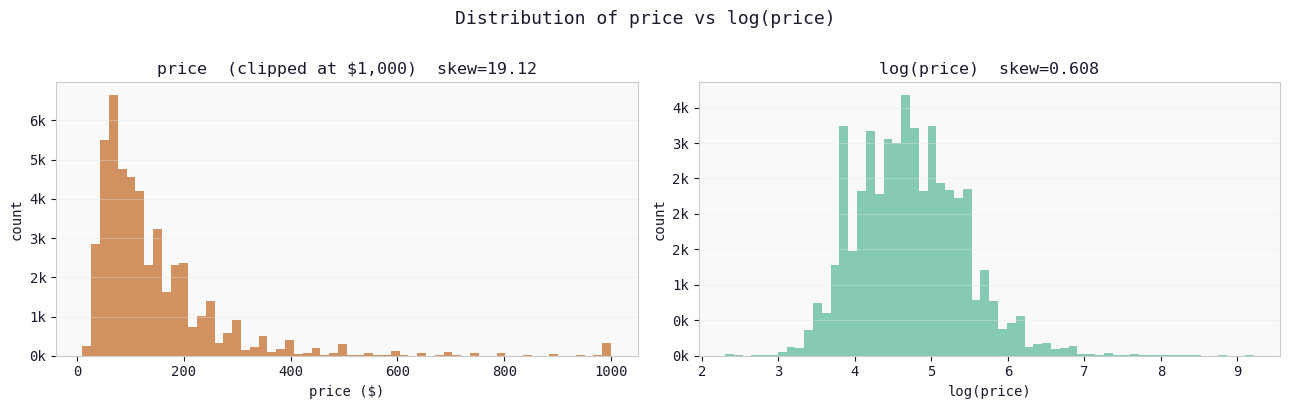

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribution of price vs log(price)', fontsize=13, y=1.01)

# Raw price (clipped at $1,000 for readability)
ax = axes[0]
clipped = df_clean['price'].clip(upper=1000)
ax.hist(clipped, bins=60, color=ACCENT2, alpha=0.8, edgecolor='none')
ax.set_title(f'price  (clipped at $1,000)  skew={sk_raw:.2f}')
ax.set_xlabel('price ($)')
ax.set_ylabel('count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.grid(axis='y', alpha=0.5)

# log(price)
ax = axes[1]
ax.hist(df_clean['log_price'], bins=60, color=ACCENT3, alpha=0.8, edgecolor='none')
ax.set_title(f'log(price)  skew={sk_log:.3f}')
ax.set_xlabel('log(price)')
ax.set_ylabel('count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/fig_target_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

### Why `log(price)` — three statistical justifications

1. **OLS residual normality (Gauss-Markov):** Raw price's skewness of 19.1 guarantees severe violations; log reduces this to 0.6.  
2. **Heteroskedasticity:** Price variance scales with the mean (luxury listings vary more). Log stabilises variance — equivalent to assuming a multiplicative error model.  
3. **Interpretation:** A coefficient β on log(price) means a one-unit increase in the feature is associated with a `e^β − 1 ≈ β × 100%` change in price, which is economically natural for pricing models.

---
## 4 · Categorical Features — Distributions & Group Differences

In [11]:
# ── Summary statistics by group ────────────────────────────────────────────
print("=== log(price) by room_type ===")
print(df_clean.groupby('room_type')['log_price'].agg(['mean','std','count']).round(3))

print("\n=== log(price) by neighbourhood_group ===")
print(df_clean.groupby('neighbourhood_group')['log_price'].agg(['mean','std','count']).round(3))

=== log(price) by room_type ===
                  mean    std  count
room_type                           
Entire home/apt  5.141  0.567  25398
Private room     4.296  0.517  22315
Shared room      3.952  0.651   1157

=== log(price) by neighbourhood_group ===
                      mean    std  count
neighbourhood_group                     
Bronx                4.244  0.595   1090
Brooklyn             4.567  0.642  20089
Manhattan            4.999  0.674  21654
Queens               4.371  0.594   5664
Staten Island        4.372  0.684    373


In [12]:
# ── Kruskal-Wallis test ────────────────────────────────────────────────────
# Non-parametric one-way test.
# Preferred over one-way ANOVA because:
#   - we cannot assume equal variances across groups (Levene's test would reject)
#   - sample sizes are unequal (Shared room: n=1,157 vs Entire home: n=25,398)
# H₀: all groups have the same distribution of log(price)

groups_rt = [df_clean[df_clean['room_type']==rt]['log_price'].values
             for rt in df_clean['room_type'].unique()]
H_rt, p_rt = kruskal(*groups_rt)

groups_nb = [df_clean[df_clean['neighbourhood_group']==nb]['log_price'].values
             for nb in df_clean['neighbourhood_group'].unique()]
H_nb, p_nb = kruskal(*groups_nb)

print(f"Kruskal-Wallis — room_type:           H={H_rt:,.1f}, p={p_rt:.2e}")
print(f"Kruskal-Wallis — neighbourhood_group: H={H_nb:,.1f}, p={p_nb:.2e}")
print()
print("Both reject H₀ at any conventional significance level.")
print("→ room_type and neighbourhood_group are strong predictors of log(price).")

Kruskal-Wallis — room_type:           H=22,408.5, p=0.00e+00
Kruskal-Wallis — neighbourhood_group: H=7,022.1, p=0.00e+00

Both reject H₀ at any conventional significance level.
→ room_type and neighbourhood_group are strong predictors of log(price).


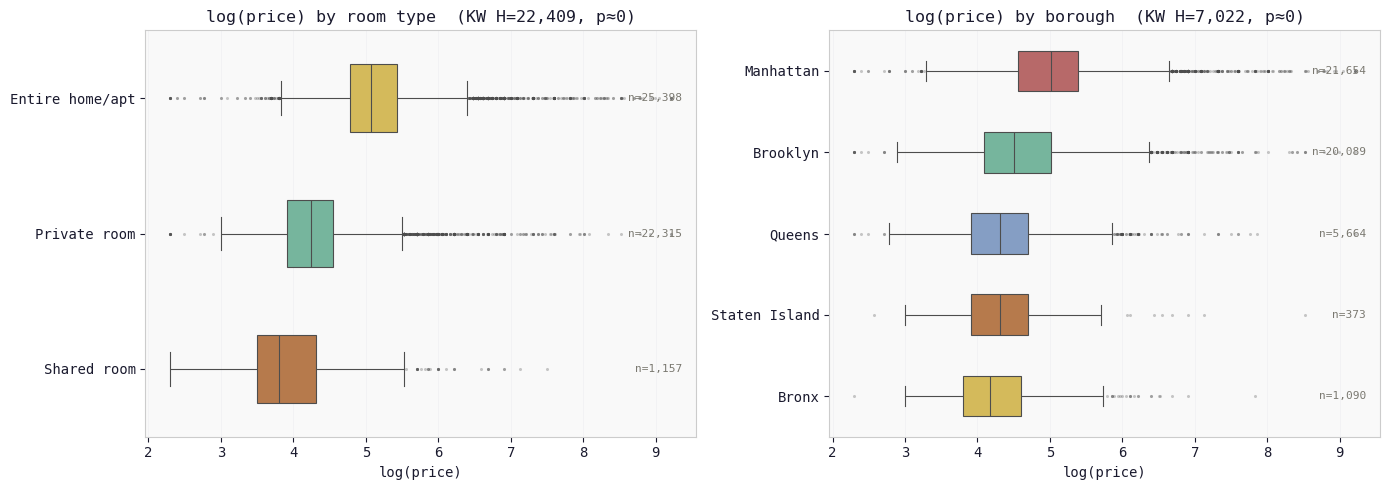

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Box plots: room_type ───────────────────────────────────────────────────
room_order = ['Entire home/apt', 'Private room', 'Shared room']
palette_rt  = {'Entire home/apt': ACCENT, 'Private room': ACCENT3, 'Shared room': ACCENT2}

ax = axes[0]
sns.boxplot(data=df_clean, x='log_price', y='room_type',
            order=room_order, palette=palette_rt,
            fliersize=1.2, flierprops={'alpha': 0.3},
            linewidth=0.8, width=0.5, ax=ax)
ax.set_title(f'log(price) by room type  (KW H={H_rt:,.0f}, p≈0)')
ax.set_xlabel('log(price)')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.5)
counts_rt = df_clean['room_type'].value_counts()
for i, rt in enumerate(room_order):
    ax.text(ax.get_xlim()[1]*0.98, i, f'n={counts_rt[rt]:,}',
            va='center', ha='right', fontsize=8, color=MUTED)

# ── Box plots: neighbourhood_group ─────────────────────────────────────────
nb_order = ['Manhattan','Brooklyn','Queens','Staten Island','Bronx']
palette_nb = dict(zip(nb_order, [DANGER, ACCENT3, ACCENT4, ACCENT2, ACCENT]))

ax = axes[1]
sns.boxplot(data=df_clean, x='log_price', y='neighbourhood_group',
            order=nb_order, palette=palette_nb,
            fliersize=1.2, flierprops={'alpha': 0.3},
            linewidth=0.8, width=0.5, ax=ax)
ax.set_title(f'log(price) by borough  (KW H={H_nb:,.0f}, p≈0)')
ax.set_xlabel('log(price)')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.5)
counts_nb = df_clean['neighbourhood_group'].value_counts()
for i, nb in enumerate(nb_order):
    ax.text(ax.get_xlim()[1]*0.98, i, f'n={counts_nb[nb]:,}',
            va='center', ha='right', fontsize=8, color=MUTED)

plt.tight_layout()
plt.savefig('figures/fig_categorical_boxplots.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

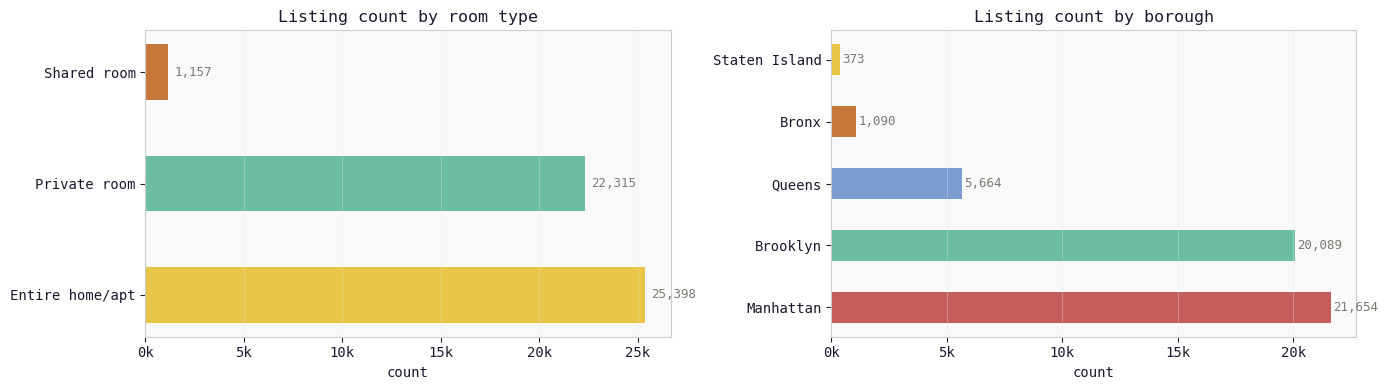

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Room type counts
rt_counts = df_clean['room_type'].value_counts()
colors_rt = [ACCENT, ACCENT3, ACCENT2]
axes[0].barh(rt_counts.index, rt_counts.values, color=colors_rt, edgecolor='none', height=0.5)
axes[0].set_title('Listing count by room type')
axes[0].set_xlabel('count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].grid(axis='x', alpha=0.5)
for i, (idx, val) in enumerate(rt_counts.items()):
    axes[0].text(val + 300, i, f'{val:,}', va='center', fontsize=9, color=MUTED)

# Borough counts
nb_counts = df_clean['neighbourhood_group'].value_counts()
colors_nb = [DANGER, ACCENT3, ACCENT4, ACCENT2, ACCENT]
axes[1].barh(nb_counts.index, nb_counts.values, color=colors_nb, edgecolor='none', height=0.5)
axes[1].set_title('Listing count by borough')
axes[1].set_xlabel('count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[1].grid(axis='x', alpha=0.5)
for i, (idx, val) in enumerate(nb_counts.items()):
    axes[1].text(val + 100, i, f'{val:,}', va='center', fontsize=9, color=MUTED)

plt.tight_layout()
plt.savefig('figures/fig_listing_counts.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Neighbourhood encoding — the key modelling decision

`neighbourhood` has **221 unique values** — a high-cardinality categorical.  
We will compare three encoding strategies in the modelling phase:

| Strategy | Dims | Risk | Mitigation |
|---|---|---|---|
| `neighbourhood_group` one-hot | 4 | Information loss (221→5) | — |
| `neighbourhood` one-hot | 220 | High variance; sparse | Ridge/Lasso regularisation |
| `neighbourhood` target encoding | 1 | **Data leakage** if computed globally | Compute **inside each CV fold** with LOO + smoothing |

---
## 5 · Numeric Features — Correlations & Distributions

In [15]:
numeric_cols = [
    'latitude', 'longitude', 'minimum_nights',
    'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365'
]

corr_results = {}
for col in numeric_cols:
    r, p = stats.pearsonr(df_clean[col], df_clean['log_price'])
    corr_results[col] = {'r': r, 'p': p}

corr_df = pd.DataFrame(corr_results).T
corr_df.columns = ['Pearson r', 'p-value']
corr_df['|r|'] = corr_df['Pearson r'].abs()
corr_df = corr_df.sort_values('|r|', ascending=False)
corr_df.round(4)

,Pearson r,p-value,|r|
longitude,-0.3261,0.0,0.3261
calculated_host_listings_count,0.1327,0.0,0.1327
availability_365,0.0988,0.0,0.0988
latitude,0.0794,0.0,0.0794
reviews_per_month,-0.0603,0.0,0.0603
number_of_reviews,-0.0423,0.0,0.0423
minimum_nights,0.0402,0.0,0.0402


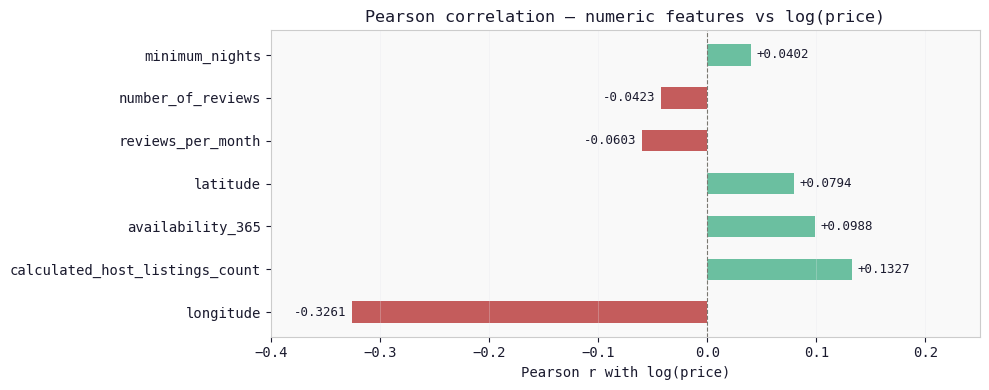

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

sorted_cols = corr_df.index.tolist()
r_vals = corr_df['Pearson r'].values
colors = [ACCENT3 if r >= 0 else DANGER for r in r_vals]

bars = ax.barh(sorted_cols, r_vals, color=colors, edgecolor='none', height=0.5)
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle='--')
ax.set_xlabel('Pearson r with log(price)')
ax.set_title('Pearson correlation — numeric features vs log(price)')
ax.grid(axis='x', alpha=0.4)
ax.set_xlim(-0.4, 0.25)

for bar, r in zip(bars, r_vals):
    label = f'{r:+.4f}'
    x = bar.get_width()
    ax.text(x + (0.005 if r >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            label, va='center', ha='left' if r >= 0 else 'right',
            fontsize=9)

plt.tight_layout()
plt.savefig('figures/fig_correlations.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Interpretation

- **`longitude`** (r = −0.326): By far the strongest numeric predictor. More negative longitude = more westward = Manhattan = higher prices. This is a geographic proxy for centrality.
- **`calculated_host_listings_count`** (r = +0.133): Hosts managing many listings tend to price higher — potentially professional operators targeting premium segments.
- **`availability_365`** (r = +0.099): More available listings tend to cost more — possibly because budget listings get booked up quickly.
- **Weak signals** (`minimum_nights`, `number_of_reviews`, `reviews_per_month`, |r| < 0.07): These have low linear correlation but may contribute via **non-linear interactions** in tree-based models.

> **⚠ Multicollinearity note:** `latitude`/`longitude` and `neighbourhood_group` encode overlapping geographic information. We will compute **VIF (Variance Inflation Factor)** in the linear modelling phase and consider dropping one representation if VIF > 10.

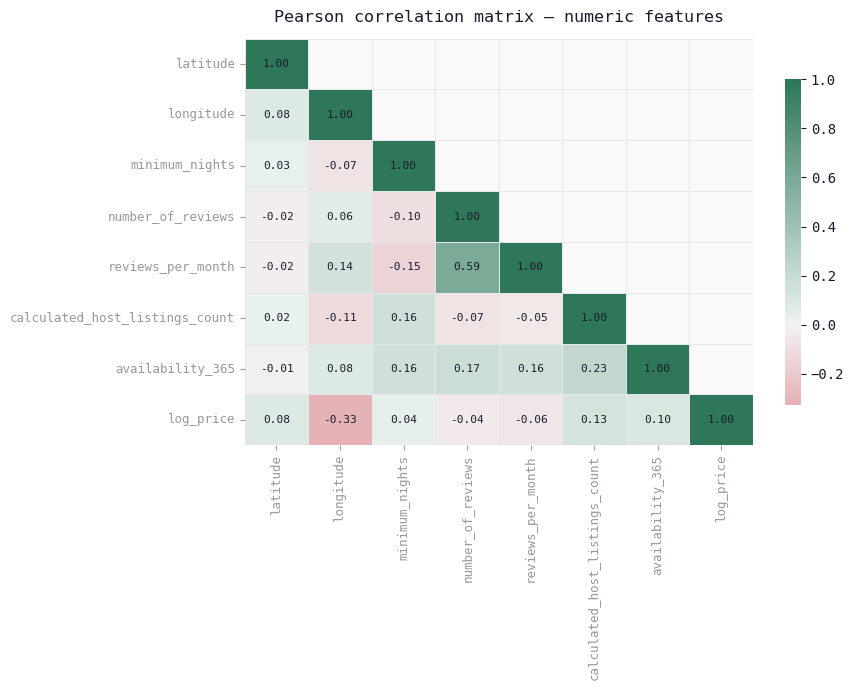

In [17]:
# ── Pairwise correlation heatmap (numeric features only) ───────────────────
numeric_data = df_clean[numeric_cols + ['log_price']].copy()
corr_matrix  = numeric_data.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle only

# Custom diverging colormap on dark background
cmap = sns.diverging_palette(10, 150, s=80, l=45, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8, 'color': '#1A1A2E'},
            linewidths=0.4, linecolor='#E5E7EB',
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Pearson correlation matrix — numeric features', pad=12)
ax.tick_params(colors='#9a9890', labelsize=9)

plt.tight_layout()
plt.savefig('figures/fig_correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
## 6 · Geographic Distribution — Spatial Price Pattern

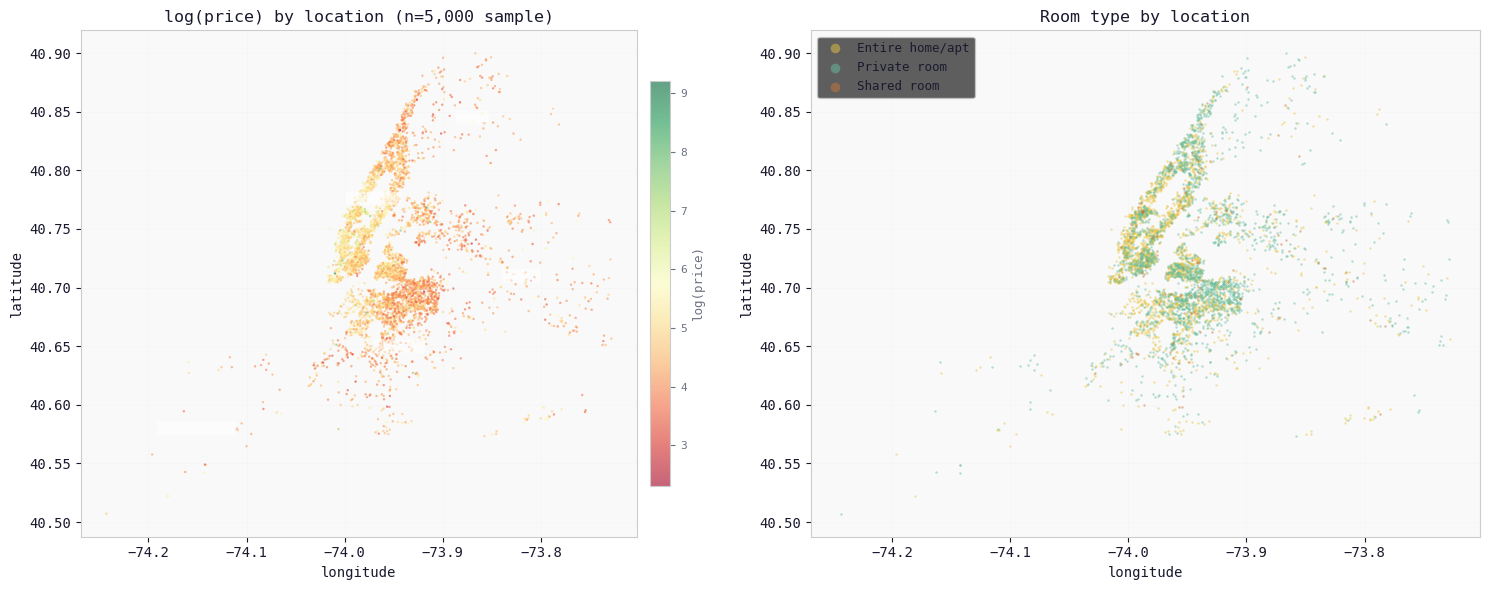

Pearson r(longitude, log_price): -0.3261
Geographic signal is strong — lat/lon included as numeric features in all models.


In [18]:
# Sample for plotting performance
geo = df_clean[['latitude','longitude','log_price','room_type',
                'neighbourhood_group']].sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: colour by log(price) ─────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(geo['longitude'], geo['latitude'],
                c=geo['log_price'], cmap='RdYlGn',
                s=3, alpha=0.6, linewidths=0)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('log(price)', color='#6B7280', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='#6B7280')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#6B7280', fontsize=8)
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
ax.set_title('log(price) by location (n=5,000 sample)')
ax.grid(alpha=0.2)

# Annotate borough regions
borough_centers = {
    'Manhattan':    (-73.971, 40.776),
    'Brooklyn':     (-73.944, 40.650),
    'Queens':       (-73.820, 40.710),
    'Bronx':        (-73.870, 40.845),
    'Staten Island':(-74.150, 40.580),
}
for name, (lon, lat) in borough_centers.items():
    ax.text(lon, lat, name, fontsize=7, color='white', alpha=0.6,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.5, edgecolor='none'))

# ── Right: colour by room_type ─────────────────────────────────────────────
ax = axes[1]
room_colors = {'Entire home/apt': ACCENT, 'Private room': ACCENT3, 'Shared room': ACCENT2}
for rt, grp in geo.groupby('room_type'):
    ax.scatter(grp['longitude'], grp['latitude'],
               c=room_colors[rt], label=rt, s=3, alpha=0.5, linewidths=0)
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
ax.set_title('Room type by location')
ax.grid(alpha=0.2)
ax.legend(loc='upper left', markerscale=4, framealpha=0.7)

plt.tight_layout()
plt.savefig('figures/fig_geographic.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Pearson r(longitude, log_price): {stats.pearsonr(df_clean['longitude'], df_clean['log_price'])[0]:.4f}")
print("Geographic signal is strong — lat/lon included as numeric features in all models.")

### Spatial autocorrelation

Prices at nearby locations tend to be similar — visible in the map above (price clusters, not noise).  
This is a potential violation of OLS's **independence of observations** assumption.  
We will formally test this with **Moran's I** on OLS residuals in the modelling phase.

---
## 7 · Neighbourhood Deep Dive — Within-Borough Price Variation

In [19]:
# Top 15 neighbourhoods by mean log(price), with sample size
top_nb = (df_clean
    .groupby('neighbourhood')['log_price']
    .agg(mean='mean', std='std', count='count')
    .sort_values('mean', ascending=False)
    .head(15)
    .reset_index())
top_nb['mean_price'] = np.exp(top_nb['mean']).round(1)
top_nb[['neighbourhood','mean','std','count','mean_price']].round(3)

,neighbourhood,mean,std,count,mean_price
0,Fort Wadsworth,6.685,NaN,1,800.0
1,Woodrow,6.551,NaN,1,700.0
2,Tribeca,5.755,0.808,177,315.8
3,Neponsit,5.590,0.281,3,267.7
4,Flatiron District,5.537,0.721,80,253.9
5,NoHo,5.530,0.541,78,252.2
6,Willowbrook,5.517,NaN,1,249.0
7,Sea Gate,5.450,1.273,7,232.8
8,Midtown,5.416,0.639,1544,225.1
9,Prince's Bay,5.391,1.203,4,219.5


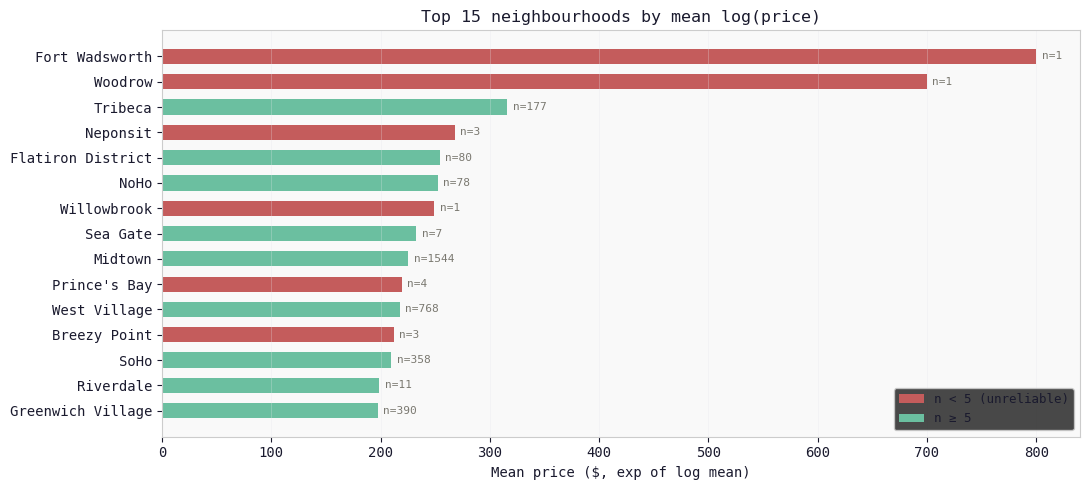

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))

colors = [DANGER if row['count'] < 5 else ACCENT3
          for _, row in top_nb.iterrows()]
bars = ax.barh(top_nb['neighbourhood'], top_nb['mean_price'],
               color=colors, edgecolor='none', height=0.6)

ax.set_xlabel('Mean price ($, exp of log mean)')
ax.set_title('Top 15 neighbourhoods by mean log(price)')
ax.grid(axis='x', alpha=0.4)
ax.invert_yaxis()

for i, row in top_nb.iterrows():
    ax.text(row['mean_price'] + 5, i, f"n={row['count']}", va='center', fontsize=8, color=MUTED)

# Legend for low-n warning
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=DANGER, label='n < 5 (unreliable)'),
                   Patch(facecolor=ACCENT3, label='n ≥ 5')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('figures/fig_top_neighbourhoods.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### ⚠ Small-sample caveat

Fort Wadsworth and Woodrow appear at the top but have n=1–2, making their means unreliable.  
This is exactly why **target encoding requires regularisation** — we apply a **leave-one-out scheme with additive smoothing** (λ-weighted toward the global mean) computed **inside each CV fold** to prevent overfitting to low-count neighbourhoods.

---
## 8 · EDA Summary & Implications for Modelling

In [21]:
print("=" * 60)
print("  DATASET SUMMARY AFTER CLEANING")
print("=" * 60)
print(f"  Total rows:                  {len(df_clean):>7,}")
print(f"  Removed (price=0):                  11")
print(f"  Removed (min_nights>365):           14")
print(f"  Features (after dropping IDs):  {df_clean.shape[1]-1:>3}")
print(f"  Target: log(price)")
print(f"    skewness:                    {stats.skew(df_clean['log_price']):>7.3f}")
print(f"    mean log(price):             {df_clean['log_price'].mean():>7.3f}")
print(f"    std  log(price):             {df_clean['log_price'].std():>7.3f}")
print()
print("  KEY PREDICTORS (by signal strength)")
print(f"  longitude (r):               {stats.pearsonr(df_clean['longitude'], df_clean['log_price'])[0]:>+7.4f}")
print(f"  room_type (KW H):           {H_rt:>8,.1f}")
print(f"  neighbourhood_group (KW H): {H_nb:>8,.1f}")
print(f"  calc_host_listings (r):      {stats.pearsonr(df_clean['calculated_host_listings_count'], df_clean['log_price'])[0]:>+7.4f}")
print()
print("  NEXT STEPS")
print("  1. Feature engineering — encoding, scaling, train/test split")
print("  2. Baseline linear models — OLS, Ridge, Lasso (with VIF check)")
print("  3. Nonlinear models — Decision Tree, Random Forest, XGBoost")
print("  4. Encoding strategy comparison (novelty 1)")
print("  5. Bootstrap prediction intervals (novelty 2)")
print("  6. Sensitivity analysis — exclude price > p99")

  DATASET SUMMARY AFTER CLEANING
  Total rows:                   48,870
  Removed (price=0):                  11
  Removed (min_nights>365):           14
  Features (after dropping IDs):   12
  Target: log(price)
    skewness:                      0.608
    mean log(price):               4.727
    std  log(price):               0.698

  KEY PREDICTORS (by signal strength)
  longitude (r):               -0.3261
  room_type (KW H):           22,408.5
  neighbourhood_group (KW H):  7,022.1
  calc_host_listings (r):      +0.1327

  NEXT STEPS
  1. Feature engineering — encoding, scaling, train/test split
  2. Baseline linear models — OLS, Ridge, Lasso (with VIF check)
  3. Nonlinear models — Decision Tree, Random Forest, XGBoost
  4. Encoding strategy comparison (novelty 1)
  5. Bootstrap prediction intervals (novelty 2)
  6. Sensitivity analysis — exclude price > p99
